### Meta Data of dataset's URLs
It is always important to carefully examine the information available and work with it in detail. As observed during the EDA, the datasets include the URLs of the news articles. These URLs can provide additional context and details about each news item, such as the source, publication date, and related metadata, which may offer valuable insights for ESG issues. Leveraging this information can enhance the analysis by allowing cross-checking of data, exploration of the original content when needed, and extraction of supplementary features that enrich the dataset.

In [1]:
import requests

In [7]:
URL = 'https://www.esgtoday.com/arabesque-ai-appoints-carolina-minio-paluello-as-new-ceo/'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
    "Referer": "https://www.google.com/"
}
response = requests.get(url=URL, headers=headers)

In [8]:
print(response.status_code)

200


In [9]:
print(response.text[:1000])

<!DOCTYPE html>
<html lang="en-US">
<head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1, minimum-scale=1">
        <style id="tb_inline_styles" data-no-optimize="1">.tb_animation_on{overflow-x:hidden}.themify_builder .wow{visibility:hidden;animation-fill-mode:both}[data-tf-animation]{will-change:transform,opacity,visibility}.themify_builder .tf_lax_done{transition-duration:.8s;transition-timing-function:cubic-bezier(.165,.84,.44,1)}[data-sticky-active].tb_sticky_scroll_active{z-index:1}[data-sticky-active].tb_sticky_scroll_active .hide-on-stick{display:none}@media(min-width:1046px){.hide-desktop{width:0!important;height:0!important;padding:0!important;visibility:hidden!important;margin:0!important;display:table-column!important;background:0!important;content-visibility:hidden;overflow:hidden!important}}@media(min-width:769px) and (max-width:1045px){.hide-tablet_landscape{width:0!important;height:0!important;padding:0!importan

In [10]:
import requests
from lxml import html

def get_all_meta_tags(url):
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    tree = html.fromstring(response.content)
    
    meta_tags = {meta.get("name", meta.get("property")): meta.get("content") 
                 for meta in tree.xpath('//meta') if meta.get("content")}
    
    return meta_tags

print(get_all_meta_tags(URL))

{'viewport': 'width=device-width, initial-scale=1, minimum-scale=1', 'robots': 'index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1', 'og:locale': 'en_US', 'og:type': 'article', 'og:title': 'Arabesque AI Appoints Carolina Minio Paluello as New CEO - ESG Today', 'og:description': 'ESG-focused financial technology company Arabesque AI announced today the appointment of Dr. Carolina Minio Paluello as the company’s new Chief Executive Officer. In her new role, Minio Paluello will lead the roll-out of the company’s AI-powered portfolio management service, the second release from Arabesque following the launch of ESG Book in 2021. The new “portfolio […]', 'og:url': 'https://www.esgtoday.com/arabesque-ai-appoints-carolina-minio-paluello-as-new-ceo/', 'og:site_name': 'ESG Today', 'article:publisher': 'https://www.facebook.com/ESGToday/', 'article:published_time': '2023-01-30T14:30:14+00:00', 'article:modified_time': '2023-01-30T14:30:17+00:00', 'og:image': 'https://www

In [11]:
URL2 = 'https://www.esgtoday.com/ukraine-war-inflation-reduction-act-driving-fossil-fuel-demand-down-renewables-higher-bp/'

print(get_all_meta_tags(URL2))

{'viewport': 'width=device-width, initial-scale=1, minimum-scale=1', 'robots': 'index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1', 'og:locale': 'en_US', 'og:type': 'article', 'og:title': 'Ukraine War, Inflation Reduction Act Driving Fossil Fuel Demand Down, Renewables Higher: bp - ESG Today', 'og:description': 'Events of past year accelerating energy transition Energy giant bp announced the release of its Energy Outlook 2023 today, exploring its scenario forecasts over the next three decades, based on global energy trends and uncertainties. Following major events over the past year – most notably the Russia-Ukraine war, in addition to the recent passage of […]', 'og:url': 'https://www.esgtoday.com/ukraine-war-inflation-reduction-act-driving-fossil-fuel-demand-down-renewables-higher-bp/', 'og:site_name': 'ESG Today', 'article:publisher': 'https://www.facebook.com/ESGToday/', 'article:published_time': '2023-01-30T13:43:07+00:00', 'article:modified_time': '2023

Unfortunately, there are no metadata features that could aid in predicting the impact level or impact length. As a result, no metadata information will be included in the analysis.

### Tables for Chapter 5 :


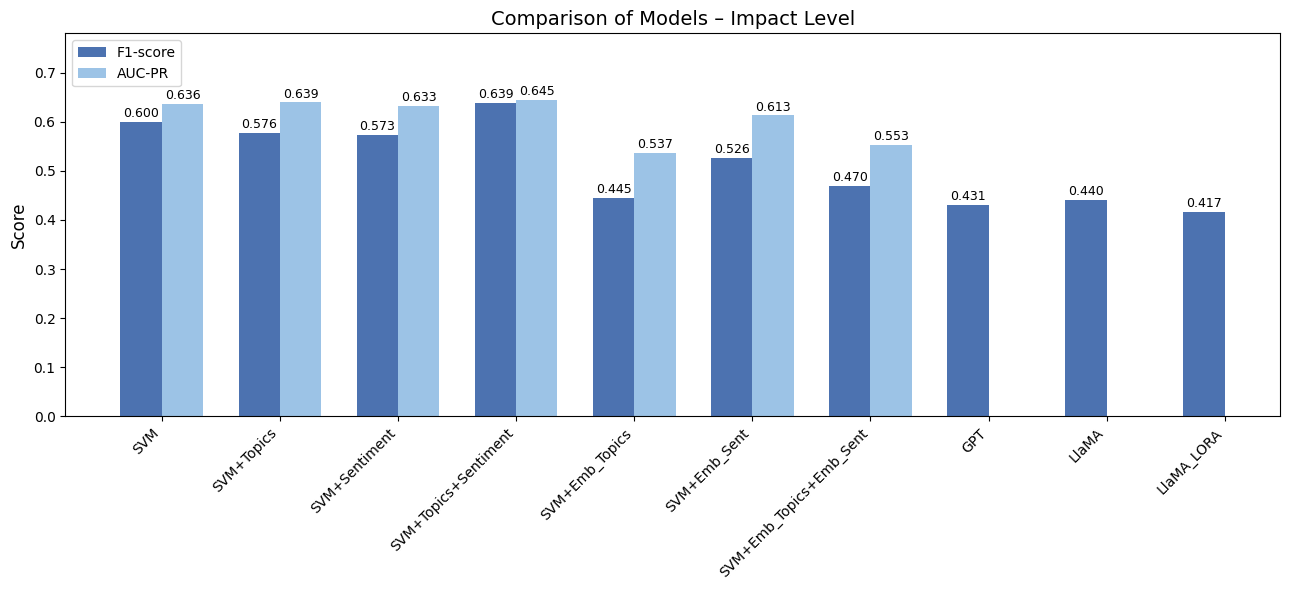

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data
models = [
    'SVM', 'SVM+Topics', 'SVM+Sentiment', 'SVM+Topics+Sentiment',
    'SVM+Emb_Topics', 'SVM+Emb_Sent', 'SVM+Emb_Topics+Emb_Sent',
    'GPT', 'LlaMA', 'LlaMA_LORA'
]

f1_scores = [0.6001, 0.5763, 0.5726 , 0.6387, 0.4448, 0.5260, 0.4699, 0.4315, 0.440, 0.417]
auc_pr =     [0.6359, 0.6393, 0.6330, 0.6447, 0.5371, 0.6129, 0.5529, np.nan, np.nan, np.nan]

# Positions
x = np.arange(len(models))
width = 0.35

# Colors
f1_color = '#4C72B0'      # blue
auc_color = '#9CC3E6'     # light blue

# Plot
plt.figure(figsize=(13,6))

bars1 = plt.bar(x - width/2, f1_scores, width, label='F1-score', color=f1_color)
bars2 = plt.bar(x + width/2, auc_pr, width, label='AUC-PR', color=auc_color)

# Labels and title
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Models – Impact Level', fontsize=14)
plt.xticks(x, models, rotation=45, ha='right')
plt.ylim(0, 0.78)
plt.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha='center', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f"{height:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


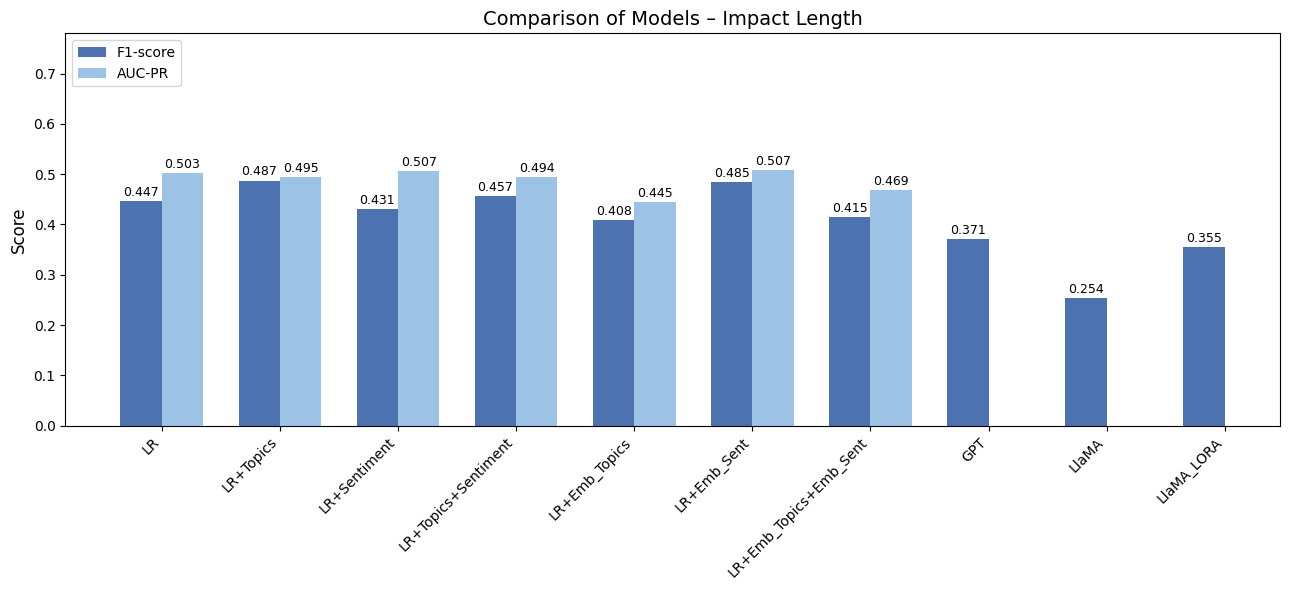

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data
models = [
    'LR', 'LR+Topics', 'LR+Sentiment', 'LR+Topics+Sentiment',
    'LR+Emb_Topics', 'LR+Emb_Sent', 'LR+Emb_Topics+Emb_Sent',
    'GPT', 'LlaMA', 'LlaMA_LORA'
]

f1_scores = [0.4466, 0.4873, 0.4308, 0.4572, 0.4083, 0.4846, 0.4153, 0.3710, 0.254, 0.355]
auc_pr =     [0.5030, 0.4950, 0.5067, 0.4942, 0.4448, 0.5073, 0.4688, np.nan, np.nan, np.nan]

# Positions
x = np.arange(len(models))
width = 0.35

# Colors
f1_color = '#4C72B0'      # blue
auc_color = '#9CC3E6'     # light blue

# Plot
plt.figure(figsize=(13,6))

bars1 = plt.bar(x - width/2, f1_scores, width, label='F1-score', color=f1_color)
bars2 = plt.bar(x + width/2, auc_pr, width, label='AUC-PR', color=auc_color)

# Labels and title
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Models – Impact Length', fontsize=14)
plt.xticks(x, models, rotation=45, ha='right')
plt.ylim(0, 0.78)
plt.legend()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.3f}", ha='center', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                 f"{height:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
models = [ "LR", "RF", "SVM", "NB", "XGB" , "LR with lemmatization", "SVM with stemming"],
f1_scores = [0.5568 ± 0.0102 , 0.5568 ± 0.0102, 0.5297 ± 0.0225, 0.5072 ± 0.0291, 0.4270 ± 0.0435, 0.5501 ± 0.0354, 0.5589 ± 0.0491],
auc_pr = [0.5916 ± 0.0030, 0.5140 ± 0.0154, 0.5842 ± 0.0153, 0.5606 ± 0.0210, 0.4683 ± 0.0123, 0.5866 ± 0.0308, 0.6322 ± 0.0249]

models = [ "LR", "RF", "SVM", "NB", "XGB", "LR with stemming", "SVM with lemmatization"],
f1_scores = [ 0.4725 ± 0.0222, 0.4145 ± 0.0256, 0.4357 ± 0.0420, 0.4167 ± 0.0320, 0.4408 ± 0.0321, 0.5055 ± 0.0277, 0.5323 ± 0.0161]
auc_pr = [0.5068 ± 0.0126, 0.4612 ± 0.0153, 0.4799 ± 0.0354, 0.4621 ± 0.0172, 0.4408 ± 0.0172, 0.4434 ± 0.0287, 0.4913 ± 0.0182],

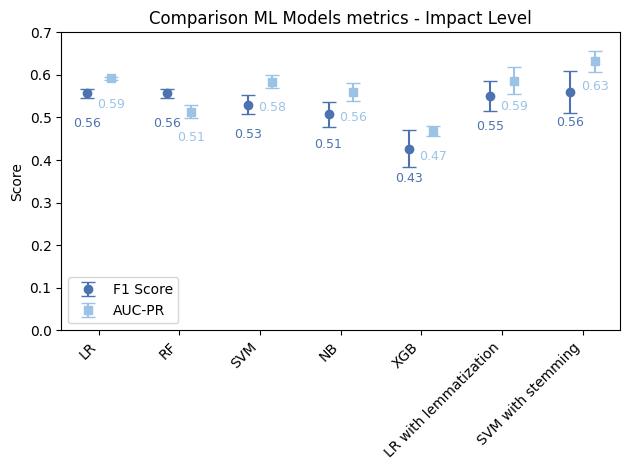

In [29]:
models = [
    "LR", "RF", "SVM", "NB", "XGB",
    "LR with lemmatization", "SVM with stemming"
]

f1_means = [0.5568, 0.5568, 0.5297, 0.5072, 0.4270, 0.5501, 0.5589]
f1_stds  = [0.0102, 0.0102, 0.0225, 0.0291, 0.0435, 0.0354, 0.0491]

auc_means = [0.5916, 0.5140, 0.5842, 0.5606, 0.4683, 0.5866, 0.6322]
auc_stds  = [0.0030, 0.0154, 0.0153, 0.0210, 0.0123, 0.0308, 0.0249]

# Colors
f1_color = '#4C72B0'
auc_color = '#9CC3E6'

x = np.arange(len(models))
offset = 0.15

plt.figure()

plt.errorbar(
    x - offset, f1_means, yerr=f1_stds,
    fmt='o', color=f1_color, capsize=5, label='F1 Score'
)

plt.errorbar(
    x + offset, auc_means, yerr=auc_stds,
    fmt='s', color=auc_color, capsize=5, label='AUC-PR'
)

for i in range(len(models)):
    plt.text(
        x[i] - offset, f1_means[i] - 0.055,
        f"{f1_means[i]:.2f}",
        ha='center', va='top', fontsize=9, color=f1_color
    )
    plt.text(
        x[i] + offset, auc_means[i] - 0.045,
        f"{auc_means[i]:.2f}",
        ha='center', va='top', fontsize=9, color=auc_color
    )

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("Score")
plt.ylim(0, 0.7)
plt.title("Comparison ML Models metrics - Impact Level")
plt.legend()
plt.tight_layout()
plt.show()


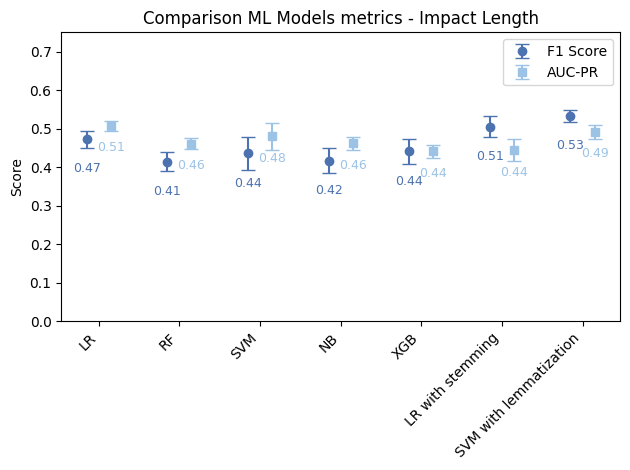

In [36]:
models = [
    "LR", "RF", "SVM", "NB", "XGB",
    "LR with stemming", "SVM with lemmatization"
]

f1_means = [0.4725, 0.4145, 0.4357, 0.4167, 0.4408, 0.5055, 0.5323]
f1_stds  = [0.0222, 0.0256, 0.0420, 0.0320, 0.0321, 0.0277, 0.0161]

auc_means = [0.5068, 0.4612, 0.4799, 0.4621, 0.4408, 0.4434, 0.4913]
auc_stds  = [0.0126, 0.0153, 0.0354, 0.0172, 0.0172, 0.0287, 0.0182]

# Colors (same as before)
f1_color = '#4C72B0'
auc_color = '#9CC3E6'

x = np.arange(len(models))
offset = 0.15

plt.figure()

plt.errorbar(
    x - offset, f1_means, yerr=f1_stds,
    fmt='o', color=f1_color, capsize=5, label='F1 Score'
)

plt.errorbar(
    x + offset, auc_means, yerr=auc_stds,
    fmt='s', color=auc_color, capsize=5, label='AUC-PR'
)

# Diagonal value labels (mean only), placed lower
for i in range(len(models)):
    plt.text(
        x[i] - offset, f1_means[i] - 0.06,
        f"{f1_means[i]:.2f}",
        ha='center', va='top', fontsize=9, color=f1_color
    )
    plt.text(
        x[i] + offset, auc_means[i] - 0.04,
        f"{auc_means[i]:.2f}",
        ha='center', va='top', fontsize=9, color=auc_color
    )

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("Score")
plt.ylim(0, 0.75)
plt.title("Comparison ML Models metrics - Impact Length")
plt.legend()
plt.tight_layout()
plt.show()